In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import langid
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import emoji
# from spellchecker.spellchecker import SpellChecker
import nltk

In [2]:
df= pd.read_csv("data/blogtext.csv")
print(f"The shape of the dataframe:{df.shape}")

The shape of the dataframe:(681284, 7)


<h1>intial checking and cleaning (dropping columns and nan values)

In [3]:
df.head()

,id,gender,age,topic,sign,date,text
0,2059027,male,15,Student,Leo,"14,May,2004","Info has been found (+/- 100 pages,..."
1,2059027,male,15,Student,Leo,"13,May,2004",These are the team members: Drewe...
2,2059027,male,15,Student,Leo,"12,May,2004",In het kader van kernfusie op aarde...
3,2059027,male,15,Student,Leo,"12,May,2004",testing!!! testing!!!
4,3581210,male,33,InvestmentBanking,Aquarius,"11,June,2004",Thanks to Yahoo!'s Toolbar I can ...


<h3> dropping sign column

* I will take only 0.1 for faster EDA and preproccing


In [4]:
ndf = df.drop(columns="sign").sample(frac=0.05,random_state=32,ignore_index=True)

In [5]:
ndf.shape

(34064, 6)

<h3>cheacking for dups, nan

In [6]:
ndf.duplicated().sum()

np.int64(48)

In [7]:
ndf.drop_duplicates(inplace=True)

In [8]:
ndf.duplicated().sum()

np.int64(0)

In [9]:
ndf.isna().sum()

id        0
gender    0
age       0
topic     0
date      0
text      0
dtype: int64

<h2> Cleaning data using regex and external libraries

<h2> Text Column

<h3> checking for non-english

* created column lang for language

In [10]:
ndf["Lang"]=ndf["text"].apply(lambda x: langid.classify(x)[0])

In [11]:
ndf["Lang"].value_counts()

Lang
en    33304
de       85
es       75
fr       58
tl       50
      ...  
eo        1
qu        1
hu        1
he        1
lo        1
Name: count, Length: 64, dtype: int64

In [12]:
def grouping(x):
    if x == "en":
        x= "en"
    else:
        x= "non-en"
    return x

In [13]:
ndf["Lang"]=ndf["Lang"].apply(lambda x:grouping(x))

In [14]:
ndf["Lang"].value_counts()

Lang
en        33304
non-en      712
Name: count, dtype: int64

<h2> Cleaning the text column

soruce: <a href= https://www.geeksforgeeks.org/nlp/text-preprocessing-for-nlp-tasks/>Geek for Geeks </a>
, <a href= https://www.geeksforgeeks.org/nlp/text-preprocessing-for-nlp-tasks/>kaggle</a>

<h3> text cleaning

In [83]:
def remove_url(text):
    pattern = re.compile(r'(https?://\S+|www\.\S+|urlink)')
    text = pattern.sub('', text)
    return text
def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r"\d+","",text) #reomve/replace numbers
    text = text.translate(str.maketrans("","",string.punctuation)) # remove punctuation
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    return text

<h3>Handling Contractions

* contraction  will be delayed until I find fix to hava runtimr

In [84]:
#def contractions_text(text):
#    expanded_text = [contractions.fix(doc) for doc in text]
#    return expanded_text


<h3>Handling Emojis and Emoticons


* will stop emojis handling becuase of logic error I will try to fix it later

In [85]:
def deEmojifiy(text):
    emoji_text = emoji.demojize(text)
    return emoji_text

<h3>tokenization</h3>

In [86]:
nltk.download('punkt_tab')
def tokenize_text(text):
    tokenized = word_tokenize(text)

    return tokenized
nltk.download('stopwords')
def removing_stop(text):
    stop_words = set(stopwords.words('english'))
    filtered_text = [word for word in text if word not in stop_words]
    return filtered_text

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Alhur\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alhur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


* spell checking will be off until I find a fix to lang_dict

In [87]:
#def spellCheking(text):
#    spell = SpellChecker()
#    corrected_text = [[spell.correction(word) for word in doc] for doc in text]
#    return corrected_text

<h3> Lemmatization

In [88]:
nltk.download('wordnet')
def lemmatization(text):
    lemmatizer = WordNetLemmatizer()
    lem_text = [lemmatizer.lemmatize(word) for word in text]
    return " ".join(lem_text)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Alhur\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


<h3> one method to rule them all

In [89]:
def preprocess_text(text):
    text = remove_url(text)
    text = clean_text(text)
#    text = contractions_text(text)
#    text = deEmojifiy(text)
    text = tokenize_text(text)
    text = removing_stop(text)
#   text = spellCheking(text)
    text = lemmatization(text)
    return text

In [91]:
ndf["text"] = ndf["text"].apply(lambda text: preprocess_text(text))

<h1> Date column

<h2> conferting date cloumn into Date

In [92]:
ndf["date_cleaned"] = pd.to_datetime(ndf["date"],errors="coerce")

In [93]:
#checking everything worked
ndf["date_cleaned"]

0       2004-07-02
1       2004-08-05
2       2004-03-30
3       2004-03-29
4       2004-04-20
           ...    
34059   2004-07-19
34060   2003-10-14
34061          NaT
34062   2003-08-14
34063   2004-08-18
Name: date_cleaned, Length: 34016, dtype: datetime64[ns]

In [94]:
ndf["date"] = ndf["date_cleaned"]

In [95]:
ndf["date"].isna().sum()

np.int64(388)

<h3> we have null in date we drop

In [96]:
ndf.dropna(inplace = True)

<h2> making date into year month day

In [97]:
ndf["year"] = ndf["date"].apply(lambda x:x.year)
ndf["month"] = ndf["date"].apply(lambda x:x.month)
ndf["day"] = ndf["date"].apply(lambda x:x.day)

In [98]:
ndf.head()

,id,gender,age,topic,date,text,Lang,date_cleaned,year,month,day
0,1999563,female,14,Student,2004-07-02,hahahha improv thing today gon na practice fun...,en,2004-07-02,2004,7,2
1,3898151,female,16,indUnk,2004-08-05,today first ok school fun playing shuwei rebec...,en,2004-08-05,2004,8,5
2,1270648,female,23,indUnk,2004-03-30,bloody likely,en,2004-03-30,2004,3,30
3,3034743,female,17,Student,2004-03-29,thing joshhaha jk suggested blog happy alex pl...,en,2004-03-29,2004,3,29
4,2402439,male,25,indUnk,2004-04-20,buy,en,2004-04-20,2004,4,20


In [99]:
#dropping date column
ndf = ndf.drop(columns=["date","date_cleaned"])

In [100]:
ndf

,id,gender,age,topic,text,Lang,year,month,day
0,1999563,female,14,Student,hahahha improv thing today gon na practice fun...,en,2004,7,2
1,3898151,female,16,indUnk,today first ok school fun playing shuwei rebec...,en,2004,8,5
2,1270648,female,23,indUnk,bloody likely,en,2004,3,30
3,3034743,female,17,Student,thing joshhaha jk suggested blog happy alex pl...,en,2004,3,29
4,2402439,male,25,indUnk,buy,en,2004,4,20
...,...,...,...,...,...,...,...,...,...
34058,3471824,female,16,Student,like said already cant think title ho hum life...,en,2004,5,28
34059,3955793,male,17,indUnk,today kind day started okay guess monday weeke...,en,2004,7,19
34060,642604,female,25,Student,site day urllink great site bit torrent use bi...,en,2003,10,14
34062,1772041,male,14,Student,hi everybody wan na thank arin whole family fl...,en,2003,8,14


<h2> Age column

<h3> making an age group

In [101]:
ndf["age"].unique()

array([14, 16, 23, 17, 25, 15, 36, 27, 48, 24, 33, 26, 13, 34, 35, 47, 40,
       38, 39, 44, 37, 45, 43, 42, 41, 46])

In [102]:
def ageGroup(x):
    if 12 <= x <=18:
        return "Teen"
    elif 19 <= x <= 29:
        return  "Young Adult"
    elif 30 <= x <= 49:
        return "Adult"
    else:
        return "Old"

In [103]:
ndf["age group"] = ndf["age"].apply(lambda x: ageGroup(x))

In [104]:
ndf["age group"]

0               Teen
1               Teen
2        Young Adult
3               Teen
4        Young Adult
            ...     
34058           Teen
34059           Teen
34060    Young Adult
34062           Teen
34063           Teen
Name: age group, Length: 33628, dtype: object

<h1> Plotting

<h2> is there an increase in non-english users based on years?

In [105]:
byYearNonEn = ndf[ndf["Lang"] =="non-en"].groupby("year").agg("count")

<Axes: xlabel='year'>

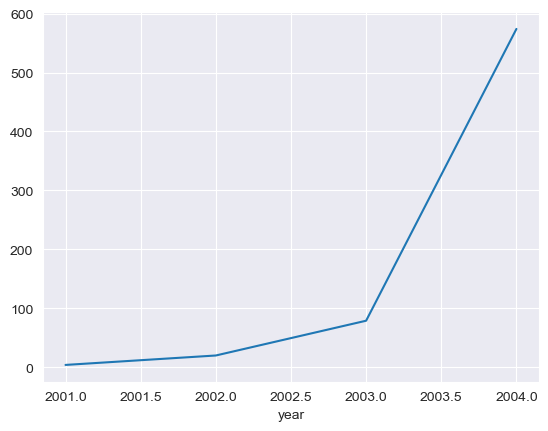

In [106]:
byYearNonEn["Lang"].plot()

<h2> how many people in each topic?

<Axes: xlabel='count', ylabel='topic'>

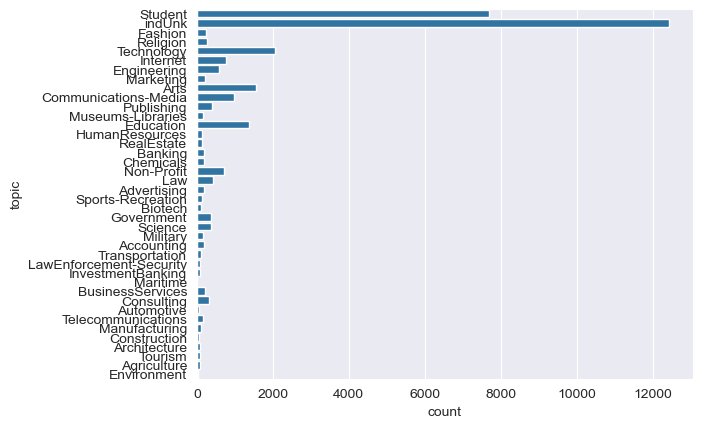

In [107]:
sns.countplot(ndf["topic"])

<h2> what age group is most common?

<Axes: xlabel='age group', ylabel='count'>

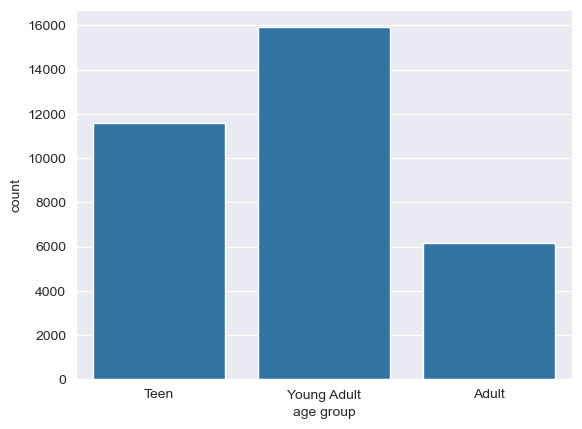

In [108]:
sns.countplot(x= ndf["age group"])

<h2>Topic by age group

<Axes: xlabel='count', ylabel='topic'>

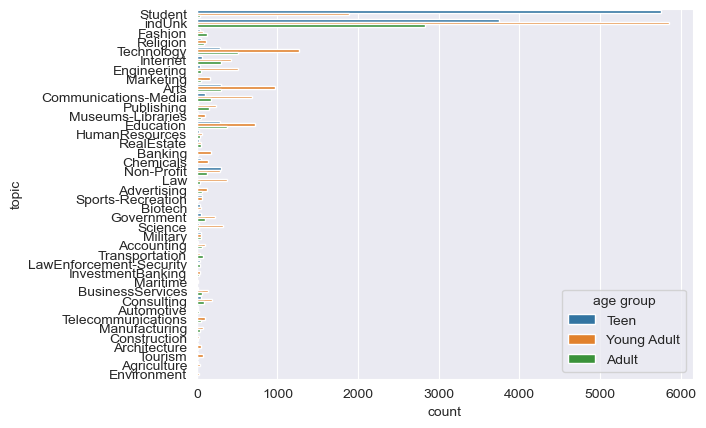

In [109]:
sns.countplot(data=ndf, y= "topic",hue="age group")

In [110]:
# for teen
ndf[ndf["age group"] == "Teen"]["topic"].value_counts()

topic
Student                    5758
indUnk                     3748
Arts                        302
Non-Profit                  297
Technology                  290
Education                   286
Communications-Media        103
Sports-Recreation            62
Internet                     59
Government                   54
Military                     53
Consulting                   49
Religion                     47
Chemicals                    47
Biotech                      43
Fashion                      42
LawEnforcement-Security      34
Engineering                  34
Science                      33
RealEstate                   32
HumanResources               30
Agriculture                  18
BusinessServices             15
Accounting                   15
Museums-Libraries            15
Architecture                 14
Automotive                   13
Tourism                      10
Publishing                   10
Advertising                   9
Transportation                7
Te

In [111]:
# for Young Adult
ndf[ndf["age group"] == "Young Adult"]["topic"].value_counts()

topic
indUnk                     5857
Student                    1884
Technology                 1263
Arts                        970
Education                   716
Communications-Media        690
Engineering                 515
Internet                    422
Law                         372
Science                     319
Non-Profit                  291
Publishing                  241
Government                  226
Consulting                  183
Banking                     170
Marketing                   163
Chemicals                   143
BusinessServices            140
Advertising                 130
Religion                    120
Telecommunications          104
Accounting                  101
Museums-Libraries           101
Fashion                      74
Manufacturing                74
Tourism                      72
Sports-Recreation            70
HumanResources               64
RealEstate                   56
Biotech                      52
Military                     51
Ar

In [112]:
# for Adult
ndf[ndf["age group"] == "Adult"]["topic"].value_counts()

topic
indUnk                     2834
Technology                  516
Education                   374
Internet                    297
Arts                        294
Communications-Media        178
Publishing                  157
Non-Profit                  129
Fashion                     125
Government                   97
Religion                     93
Consulting                   87
Transportation               76
Accounting                   65
Advertising                  63
BusinessServices             59
Telecommunications           57
Museums-Libraries            56
Military                     56
Marketing                    52
RealEstate                   46
Engineering                  46
HumanResources               45
Student                      43
LawEnforcement-Security      42
Law                          41
Manufacturing                35
InvestmentBanking            31
Science                      26
Automotive                   25
Construction                 19
Ar

<h2> who is more active on the site gender-wise

<Axes: xlabel='gender', ylabel='count'>

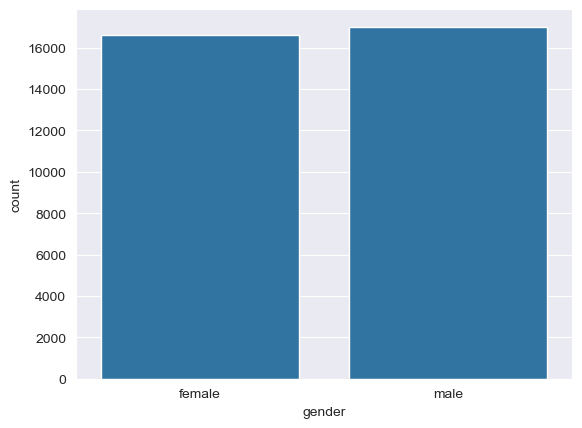

In [113]:
sns.countplot(x= ndf["gender"])

<h2> Topic by Gender

<Axes: xlabel='count', ylabel='topic'>

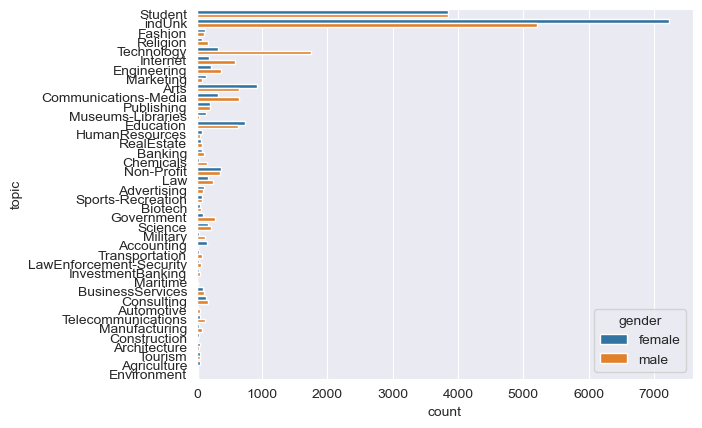

In [114]:
sns.countplot(data=ndf, y= "topic",hue="gender")

In [115]:
# for male
ndf[ndf["gender"] == "male"]["topic"].value_counts()

topic
indUnk                     5206
Student                    3841
Technology                 1746
Arts                        645
Communications-Media        643
Education                   638
Internet                    586
Engineering                 371
Non-Profit                  352
Government                  276
Law                         244
Science                     214
Publishing                  199
Consulting                  178
Religion                    177
Chemicals                   155
Military                    128
Telecommunications          119
BusinessServices            113
Banking                     110
Fashion                     110
Advertising                  92
Transportation               84
Marketing                    77
RealEstate                   76
Sports-Recreation            75
Manufacturing                75
LawEnforcement-Security      60
Biotech                      57
HumanResources               54
InvestmentBanking            48
To

In [116]:
# for female
ndf[ndf["gender"] == "female"]["topic"].value_counts()

topic
indUnk                     7233
Student                    3844
Arts                        921
Education                   738
Non-Profit                  365
Communications-Media        328
Technology                  323
Engineering                 224
Publishing                  209
Internet                    192
Law                         176
Science                     164
Accounting                  156
Marketing                   144
Consulting                  141
Museums-Libraries           137
Fashion                     131
Advertising                 110
Government                  101
BusinessServices            101
HumanResources               85
Religion                     83
Banking                      82
Sports-Recreation            72
RealEstate                   58
Biotech                      52
Tourism                      51
Telecommunications           49
Architecture                 47
Agriculture                  46
Manufacturing                35
Ch

<h2> top 5 active users

In [117]:
ndf["id"].value_counts()

id
449628     206
589736     130
1975546    127
1107146    126
942828     111
          ... 
1043329      1
3586837      1
3323220      1
4265680      1
3433815      1
Name: count, Length: 9286, dtype: int64

In [118]:
top_5 = list(ndf["id"].value_counts(sort=True)[:5].index)

In [119]:
top_5_df = ndf[ndf["id"].isin(top_5)]

In [120]:
top_5_df

,id,gender,age,topic,text,Lang,year,month,day,age group
159,449628,male,34,indUnk,world part friend gb replied first message wou...,en,2002,4,5,Adult
187,942828,female,34,indUnk,day famous catalan architect antonio gaudi die...,en,2003,6,9,Adult
237,449628,male,34,indUnk,death spam pineapple sauce continuing traditio...,en,2003,2,3,Adult
280,942828,female,34,indUnk,many thanks mr john cahill urllink inn end wor...,en,2003,11,10,Adult
282,1975546,female,23,indUnk,happy winter solstice,en,2004,8,10,Young Adult
...,...,...,...,...,...,...,...,...,...,...
33915,1975546,female,23,indUnk,static thats affirmative red static,en,2004,8,10,Young Adult
33971,1107146,female,16,Student,hmmmmwhat happened call dont call tonightand f...,en,2004,7,2,Teen
33972,1975546,female,23,indUnk,nick,en,2004,8,10,Young Adult
34018,1975546,female,23,indUnk,lmgdao website damn funny picturesmanim tearsa...,en,2004,8,10,Young Adult
